Shape of dataset: (920, 16)

Data Types:
 id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Statistical Summary:
                id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.

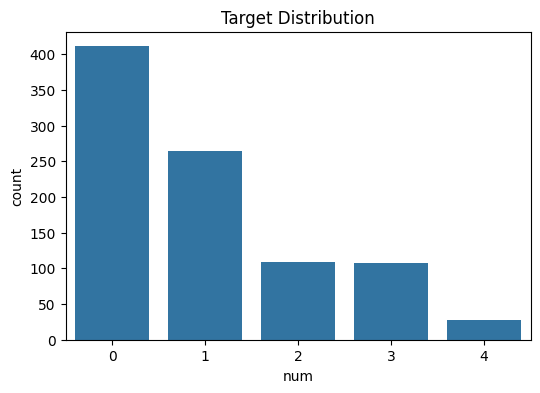

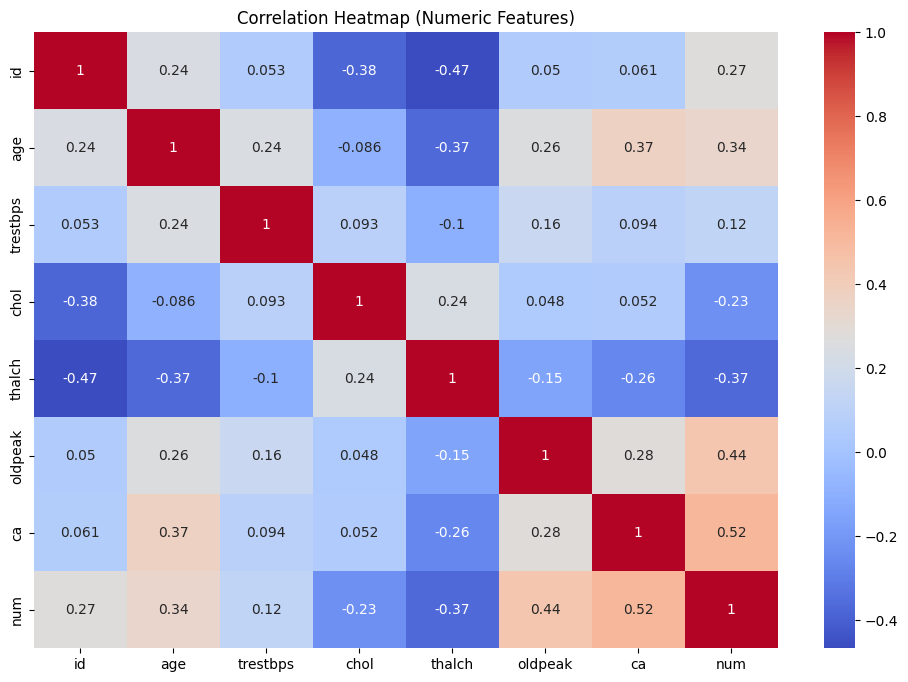

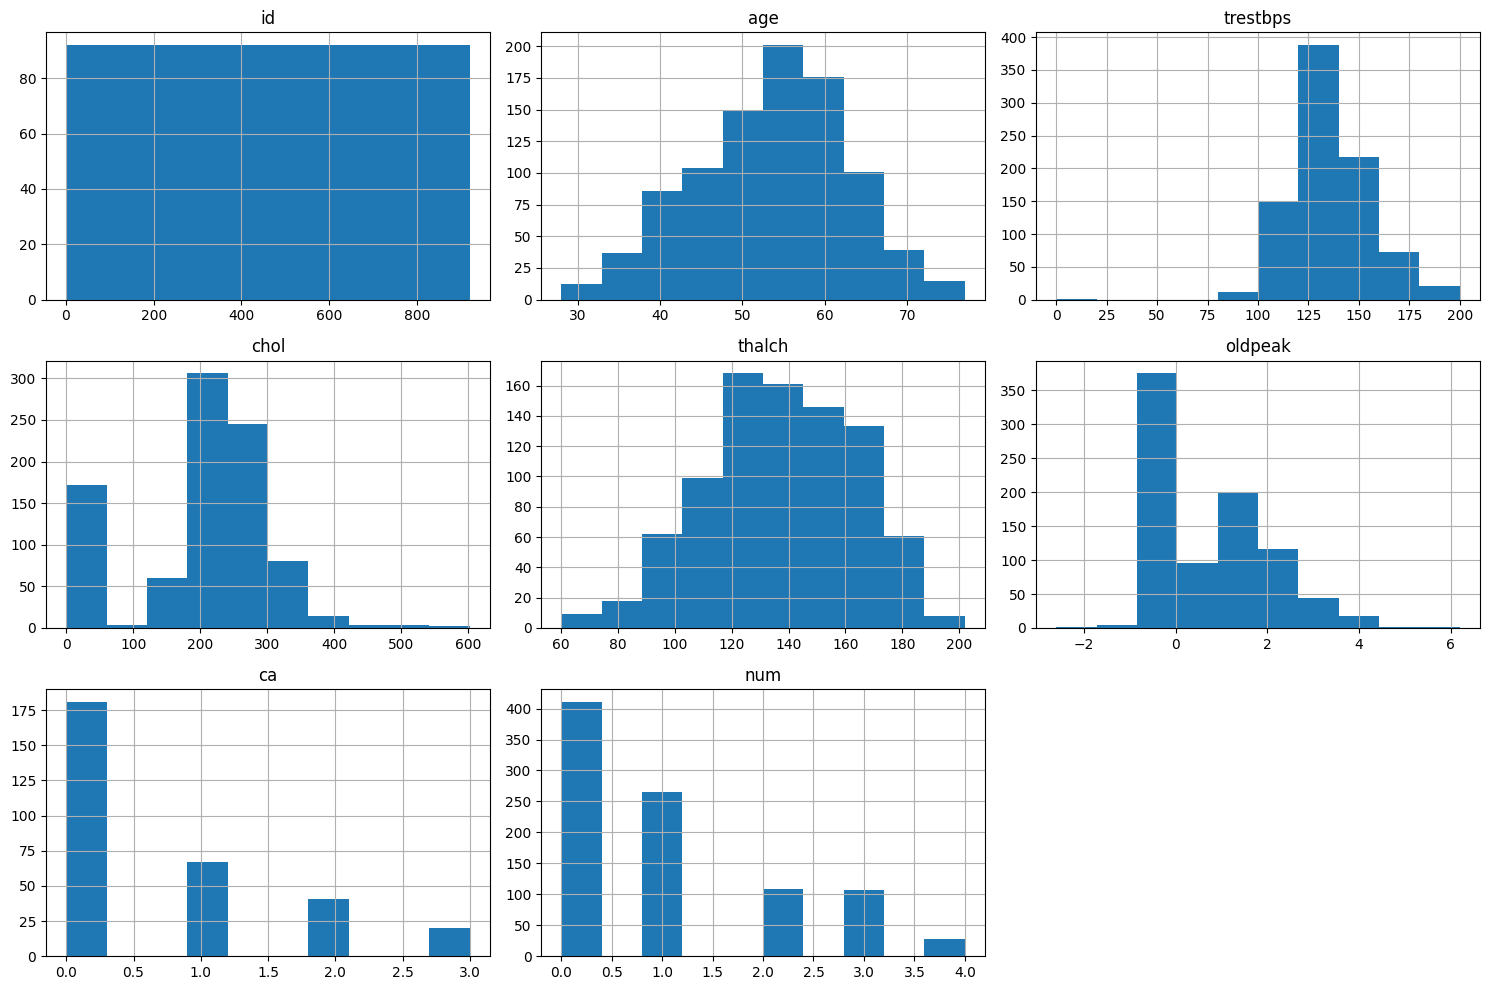

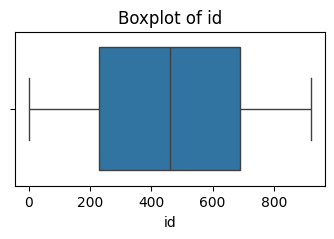

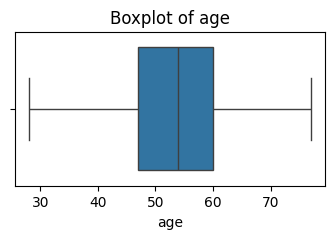

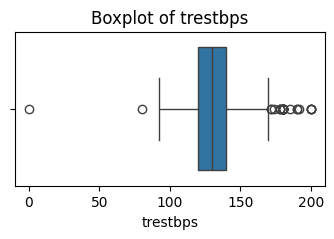

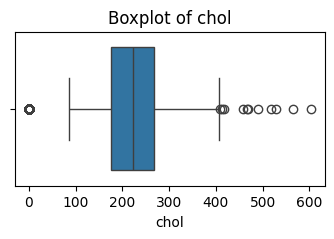

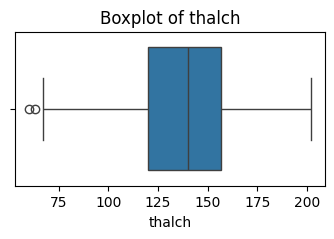

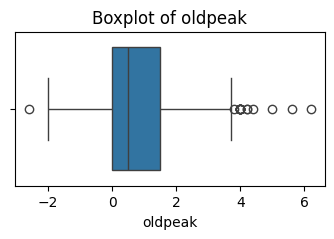

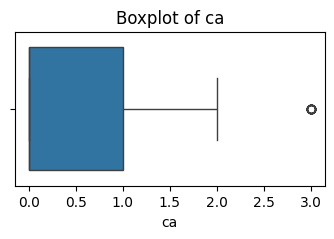

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/raw/heart_disease_uci.csv")

print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Basic statistics
print("\nStatistical Summary:\n", df.describe())

# -----------------------------
# TARGET COLUMN CHECK
# -----------------------------

if "num" in df.columns:
    target_col = "num"
elif "HeartDisease" in df.columns:
    target_col = "HeartDisease"
else:
    raise ValueError("Target column not found!")

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

# -----------------------------
# NUMERIC CORRELATION HEATMAP
# -----------------------------

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# -----------------------------
# HISTOGRAMS FOR NUMERIC FEATURES
# -----------------------------

numeric_df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# -----------------------------
# BOXPLOTS FOR OUTLIER CHECK
# -----------------------------

for column in numeric_df.columns:
    if column != target_col:
        plt.figure(figsize=(4,2))
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")
        plt.show()